In [1]:
#pentru a putea folosi TPU, am sters JAX peuntru a preveni conflictele de dependente
# si am instalat versiunea de TF 2.18.0 optimizata pt  si driverele libtpu de la Google
!export PATH="${HOME}/.local/bin:${PATH}" && uv pip uninstall --system jax jaxlib
!export PATH="${HOME}/.local/bin:${PATH}" && uv pip install --system tensorflow-tpu==2.18.0 --find-links https://storage.googleapis.com/libtpu-tf-releases/index.html

Using Python 3.12.13 environment at: /usr/local
Uninstalled 2 packages in 233ms
 - jax==0.9.2
 - jaxlib==0.9.2
Using Python 3.12.13 environment at: /usr/local
Resolved 38 packages in 427ms                                        
Prepared 6 packages in 4.76s                                             
Uninstalled 5 packages in 272ms
Installed 6 packages in 3.89s                               
 - libtpu==0.0.17
 + libtpu==2.18.0
 - ml-dtypes==0.5.4
 + ml-dtypes==0.4.1
 - numpy==2.4.3
 + numpy==2.0.2
 - protobuf==7.34.0
 + protobuf==5.29.6
 - tensorboard==2.20.0
 + tensorboard==2.18.0
 + tensorflow-tpu==2.18.0


In [2]:
import tensorflow as tf
from kaggle_datasets import KaggleDatasets
import numpy as np
import keras

print("Tensorflow version " + tf.__version__)
print("kaggle version" +  keras.__version__)

E0000 00:00:1776186701.994124      12 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


Tensorflow version 2.18.0
kaggle version3.13.2


In [3]:
#initializare TPU
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local') 
    print('Running on TPU ', tpu.master())
    
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    
except ValueError as e:
    print("TPU connection failed:", e)
    tpu = None
    strategy = tf.distribute.get_strategy()

print("REPLICAS: ", strategy.num_replicas_in_sync)

Running on TPU  
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1776186725.803447      12 service.cc:148] XLA service 0x5d47ee092510 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776186725.803480      12 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1776186725.803483      12 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1776186725.803486      12 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1776186725.803488      12 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1776186725.803490      12 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1776186725.803492      12 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1776186725.803494      12 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1776186725.803496      12 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [8]:
# === Preprocesare și Augmentare Date ===
#
# Datasetul FER2013 conține imagini faciale de 48×48 px în grayscale, organizate
# în 7 clase de emoții: Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral.
#
# Split-ul folosit:
#   - Train:      80% din directorul train_dir  (~22.968 imagini)
#   - Validare:   20% din directorul train_dir  (~5.742 imagini)
#   - Test:       directorul test_dir           (~7.178 imagini)
#
# Augmentare aplicată pe setul de antrenare:
#   - Rescaling [0, 1]
#   - Rotație aleatorie ±10%
#   - Translație ±10% (H și W)
#   - Zoom aleatoriu ±10%
#   - Flip orizontal
#   - Contrast aleatoriu ±20%
#
# Validarea și testul primesc exclusiv rescaling, fără augmentare.
# Batch size: 512.
# Pipeline optimizat cu shuffle(5000) + prefetch(AUTOTUNE).
import tensorflow as tf
from tensorflow.keras import layers

train_dir = '/kaggle/input/datasets/msambare/fer2013/train'
test_dir = '/kaggle/input/datasets/msambare/fer2013/test'

img_size = 48
batch_size = 512  # better for TPU v3-8
num_classes = 7
epoci = 100        # more epochs

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.20, subset="training", seed=123,
    image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.20, subset="validation", seed=123,
    image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(img_size, img_size), batch_size=batch_size,
    color_mode="grayscale", label_mode="categorical", shuffle=False
)

data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2)
])

rescaling_only = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

train_ds = (train_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .shuffle(5000, reshuffle_each_iteration=True)
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

val_ds = (val_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .map(lambda x, y: (rescaling_only(x, training=False), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds = (test_ds
    .unbatch()
    .batch(batch_size, drop_remainder=True)
    .map(lambda x, y: (rescaling_only(x, training=False), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


Generăm variante augmentate corect...


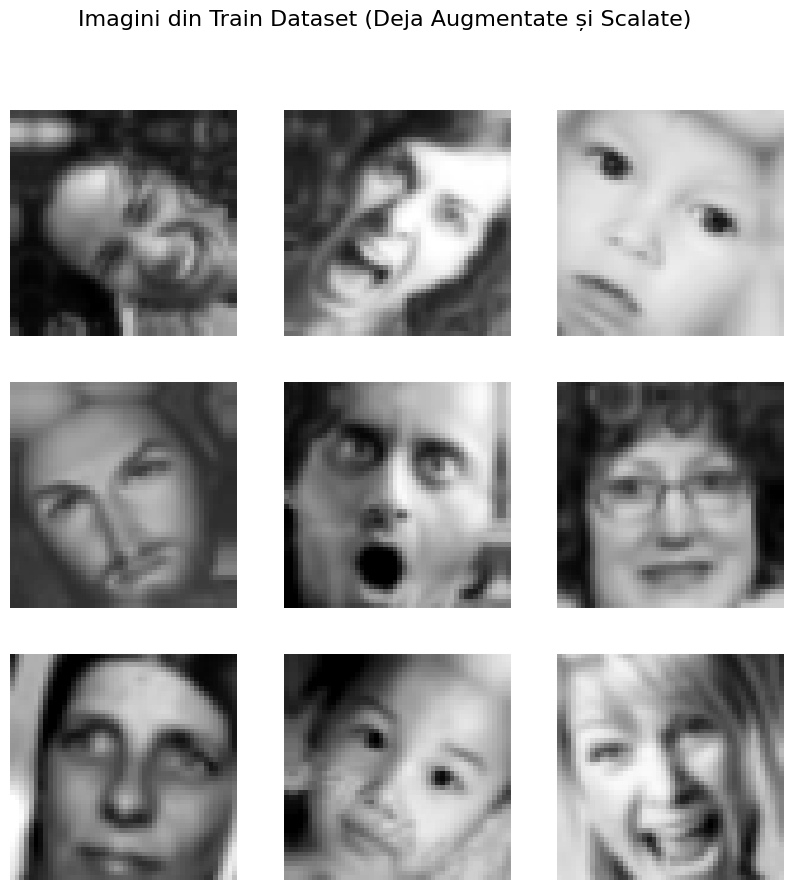

In [10]:
# === Vizualizare Imagini Augmentate ===
#
# Extragem primul batch din train_ds și afișăm 9 imagini într-un grid 3×3.
# Imaginile sunt deja procesate de pipeline:
#   - Rescalate în intervalul [0, 1]
#   - Augmentate aleatoriu (rotație, zoom, flip, translație, contrast)
#
# Scopul: validare vizuală că pipeline-ul funcționează corect
# înainte de a începe antrenarea modelului.
import matplotlib.pyplot as plt
import numpy as np

print("Generăm variante augmentate corect...")

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle("Imagini din Train Dataset (Deja Augmentate și Scalate)", fontsize=16)
    plt.show()

In [11]:
#pt fer-2013 aratam etichetele fiecarei emotii adica un numar 
clase = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
class_labels = {name: i for i, name in enumerate(clase)}

print("Etichete (valabile pentru Antrenament, Validare și Test):")
print(class_labels)

print(f"\nVerificare clase detectate: {len(clase)} emoții")
for i, emotion in enumerate(clase):
    print(f"Index {i} -> {emotion}")

Etichete (valabile pentru Antrenament, Validare și Test):
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Verificare clase detectate: 7 emoții
Index 0 -> angry
Index 1 -> disgust
Index 2 -> fear
Index 3 -> happy
Index 4 -> neutral
Index 5 -> sad
Index 6 -> surprise


In [76]:
# === Arhitectură VRES-CNN (Dogaru & Dogaru, 2023) ===
# Implementare adaptată pentru FER2013 (48×48 grayscale, 7 clase emoții).
# Structură: 3 blocuri convoluționale cu [64, 128, 64] filtre, fiecare bloc conținând
# straturi Conv2D + ReLU, BatchNormalization, MaxPooling și Dropout(0.5).
# Capul de clasificare: GlobalAveragePooling2D → Dense(7, softmax).
# Compilat cu Adam + categorical crossentropy. Instanțiat în scopul strategiei TPU.
import numpy as np
import tensorflow as tf
from keras.layers import (Input, SeparableConv2D, Conv2D, Activation, 
                           BatchNormalization, Add, MaxPooling2D, 
                           GlobalAveragePooling2D, Flatten, Dense, Dropout)
from keras.models import Model

def svcnn_resblock(x, filters, nl, resid=True, separ=True):
    csize = 3
    stri = 2
    psiz = 3
    pad = 'same'
    drop1 = 0.25

    def conv_bn_relu(inp):
        if separ:
            out = SeparableConv2D(filters, padding=pad, kernel_size=(csize, csize))(inp)
        else:
            out = Conv2D(filters, padding=pad, kernel_size=(csize, csize))(inp)
        out = BatchNormalization()(out)
        out = Activation('relu')(out)
        return out

    # match original paper: nl intermediate convs + 1 final = nl+1 total
    y = conv_bn_relu(x)
    for _ in range(nl):
        y = conv_bn_relu(y)

    if resid:
        if x.shape[-1] != filters:
            shortcut = Conv2D(filters, kernel_size=1, padding=pad)(x)
            shortcut = BatchNormalization()(shortcut)
        else:
            shortcut = x
        out = Add()([shortcut, y])
    else:
        out = y

    out = MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding=pad)(out)
    out = Dropout(drop1)(out)
    return out

def create_vres_cnn_fer(input_shape=(48, 48, 1), num_classes=7,
                         flat=0, fil=[64, 128, 256], nl=[3, 2, 2],  # increased nl
                         hid=[256], resid=True, separ=True):
    nfilmax = len(fil)
    inputs = Input(shape=input_shape)

    t = svcnn_resblock(inputs, fil[0], nl[0], resid, separ)
    for layer in range(1, nfilmax):
        t = svcnn_resblock(t, fil[layer], nl[layer], resid, separ)

    if flat == 1:
        t = Flatten()(t)
    else:
        t = GlobalAveragePooling2D()(t)

    if len(hid) > 0:
        for units in hid:
            t = Dense(units, activation='relu')(t)
            t = Dropout(0.3)(t)

    t = Dropout(0.4)(t)
    outputs = Dense(num_classes, activation='softmax')(t)
    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

with strategy.scope():
    model = create_vres_cnn_fer(
        input_shape=(48, 48, 1),
        num_classes=7,
        flat=0,
        fil=[64, 128, 256],   # back to this
        nl=[3, 2, 2],
        hid=[256],
        resid=True,
        separ=True
    )

model.summary()


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1… │ (None, 48, 48,    │        137 │ input_layer_29[0… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1… │ (None, 48, 48,    │      4,736 │ activation_98[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_99       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1… │ (None, 48, 48,    │      4,736 │ activation_99[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_100      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1… │ (None, 48, 48,    │      4,736 │ activation_100[0… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 48, 48,    │        128 │ input_layer_29[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_101      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_43 (Add)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_101[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 24, 24,    │          0 │ add_43[0][0]    

 Total params: 345,424 (1.32 MB)

 Trainable params: 341,712 (1.30 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [77]:
# Callbacks: salvare best model (val_accuracy), early stopping (patience=20),
# reducere LR la platou (factor=0.5, patience=7, min_lr=1e-6).
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "v_cnn_best_model_tpu.keras",
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=15,       
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5, 
    patience=6,          
    min_lr=1e-6,         
    verbose=1
)


In [78]:
# === Antrenare Model ===
# Se lansează antrenarea pe TPU pentru maximum 100 epoci, cu validare la fiecare epocă.
# Callbacks active: checkpoint (best model), early stopping (patience=20), ReduceLROnPlateau.
# Timpul de antrenare este cronometrat pentru a fi raportat ulterior.
import time

print("Începem antrenamentul pe TPU...")

t_start_train = time.time()
istoric_antrenare = model.fit(
    train_ds,
    epochs=epoci,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping, lr_scheduler]
)
t_end_train = time.time()

Începem antrenamentul pe TPU...
Epoch 1/100


I0000 00:00:1774989855.121247     217 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:5158791950344177777
I0000 00:00:1774989855.847461    1404 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(5378767694872371780), session_name()


      4/Unknown 21s 44ms/step - accuracy: 0.1647 - loss: 3.4046

I0000 00:00:1774989872.178225    1404 tpu_compile_op_common.cc:245] Compilation of 5378767694872371780 with session name  took 16.33072459s and succeeded
I0000 00:00:1774989872.212095    1404 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(5378767694872371780), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_5158791950344177777", property.function_library_fingerprint = 12779743483418347009, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1774989872.212131    1404 tpu_compilation_cache_interface.cc:542] After adding entry for key 5378767694872371780 with 

     43/Unknown 22s 38ms/step - accuracy: 0.1985 - loss: 2.4641

...


Epoch 96: val_accuracy did not improve from 0.61168
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6078 - loss: 1.2740 - val_accuracy: 0.6046 - val_loss: 1.2750 - learning_rate: 1.2500e-04
Epoch 97/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6427 - loss: 1.2326

I0000 00:00:1774990369.090635  447323 tpu_compile_op_common.cc:108] TpuCompileOp was cancelled. Sleeping for 300 seconds to give time for TPUCompileOp to finished.



Epoch 97: val_accuracy improved from 0.61168 to 0.61186, saving model to v_cnn_best_model_tpu.keras

Epoch 97: finished saving model to v_cnn_best_model_tpu.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6084 - loss: 1.2792 - val_accuracy: 0.6119 - val_loss: 1.2475 - learning_rate: 1.2500e-04
Epoch 98/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6190 - loss: 1.2623
Epoch 98: val_accuracy did not improve from 0.61186
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6051 - loss: 1.2806 - val_accuracy: 0.6108 - val_loss: 1.2606 - learning_rate: 1.2500e-04
Epoch 99/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6052 - loss: 1.2714
Epoch 99: val_accuracy did not improve from 0.61186
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.6070 - loss: 1.2715 - val_accuracy: 0.6016 - val_loss: 1.2719 - learning_rate: 1.2500e-04
Epoch 100/100


I0000 00:00:1774990380.960155  448572 tpu_compile_op_common.cc:108] TpuCompileOp was cancelled. Sleeping for 300 seconds to give time for TPUCompileOp to finished.


43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6121 - loss: 1.2474
Epoch 100: val_accuracy did not improve from 0.61186
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.6080 - loss: 1.2709 - val_accuracy: 0.6023 - val_loss: 1.2619 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 97.


In [80]:
# === Evaluare Model Final ===
# Se încarcă cel mai bun model salvat de checkpoint și se evaluează pe test set.
# Se raportează: timpul total de antrenare (minute), numărul de parametri,
# acuratețea pe test și latența medie de inferență per imagine (ms).
import time
import tensorflow as tf
timp_total_minute = int(t_end_train - t_start_train) / 60
print('Training with  ',epoci,' epochs, lasted  ',timp_total_minute,' minutes')

model_salvat = tf.keras.models.load_model("v_cnn_best_model_tpu.keras")

print('Număr total de parametri:', model_salvat.count_params())

t1_eval = time.time()
score = model_salvat.evaluate(test_ds, verbose=0)
t2_eval = time.time()

print(f'Cea mai buna acuratete de validare: {score[1] * 100}%')

numar_imagini_test=7178

timp_total_ms = (t2_eval - t1_eval) * 1000
latenta_per_imagine = timp_total_ms / numar_imagini_test

print(f'Latența la predicție (per imagine): {latenta_per_imagine:.4f} ms')



Training with   100  epochs, lasted   8.966666666666667  minutes
Număr total de parametri: 345424
Cea mai buna acuratete de validare: 56.09375238418579%
Latența la predicție (per imagine): 1.4959 ms


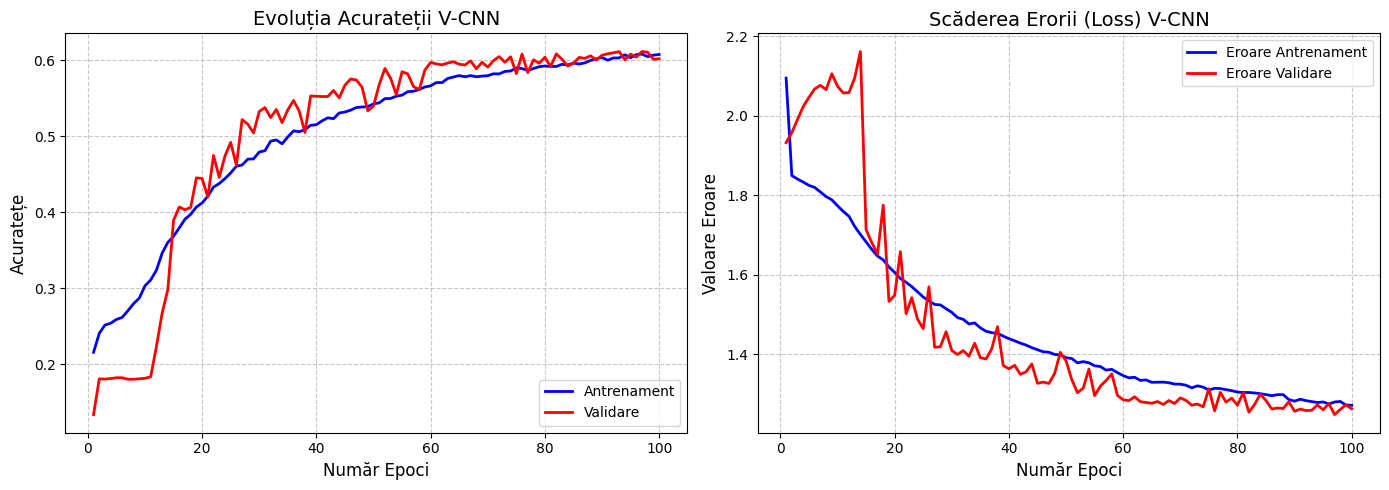

In [81]:
#graficele pentru evolutia acuratetii si scaderea erorii
#pentru setul de date de antrenament si validare
import matplotlib.pyplot as plt


acc = istoric_antrenare.history['accuracy']
val_acc = istoric_antrenare.history['val_accuracy']
loss = istoric_antrenare.history['loss']
val_loss = istoric_antrenare.history['val_loss']

epoci_rulate = range(1, len(acc) + 1)


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epoci_rulate, acc, 'b-', linewidth=2, label='Antrenament')
plt.plot(epoci_rulate, val_acc, 'r-', linewidth=2, label='Validare')
plt.title('Evoluția Acurateții V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Acuratețe', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.plot(epoci_rulate, loss, 'b-', linewidth=2, label='Eroare Antrenament')
plt.plot(epoci_rulate, val_loss, 'r-', linewidth=2, label='Eroare Validare')
plt.title('Scăderea Erorii (Loss) V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Valoare Eroare', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

Calculăm predicțiile pe setul de test...
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step


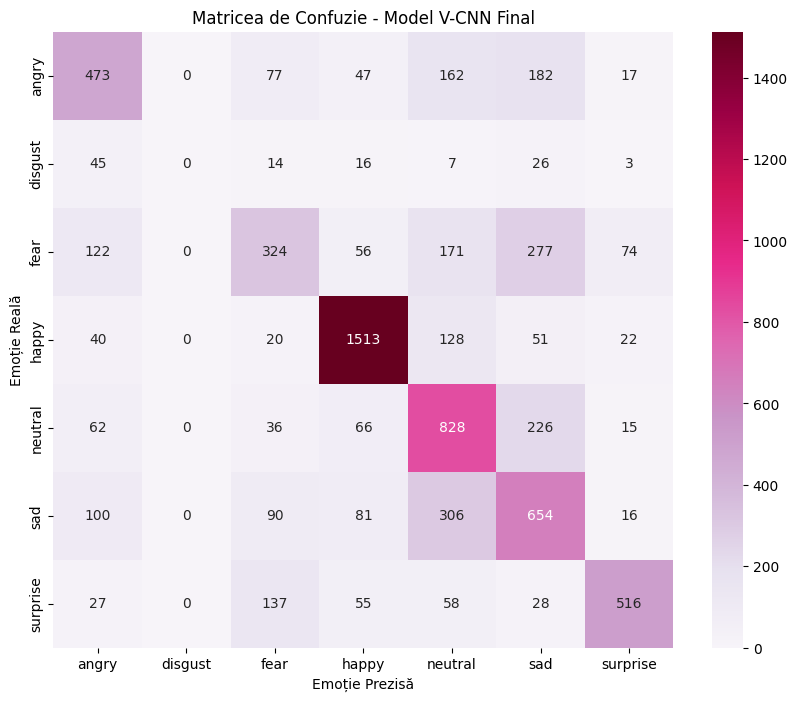


Raport de Clasificare Detaliat:

              precision    recall  f1-score   support

       angry       0.54      0.49      0.52       958
     disgust       0.00      0.00      0.00       111
        fear       0.46      0.32      0.38      1024
       happy       0.82      0.85      0.84      1774
     neutral       0.50      0.67      0.57      1233
         sad       0.45      0.52      0.49      1247
    surprise       0.78      0.63      0.70       821

    accuracy                           0.60      7168
   macro avg       0.51      0.50      0.50      7168
weighted avg       0.60      0.60      0.59      7168



In [12]:
#afisarea matricei de confuzie
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("Calculăm predicțiile pe setul de test...")

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

etichete = clase 

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=etichete, yticklabels=etichete)
plt.title('Matricea de Confuzie - Model V-CNN Final')
plt.ylabel('Emoție Reală')
plt.xlabel('Emoție Prezisă')
plt.show()

print("\nRaport de Clasificare Detaliat:\n")
print(classification_report(y_true, y_pred, target_names=etichete, zero_division=0))

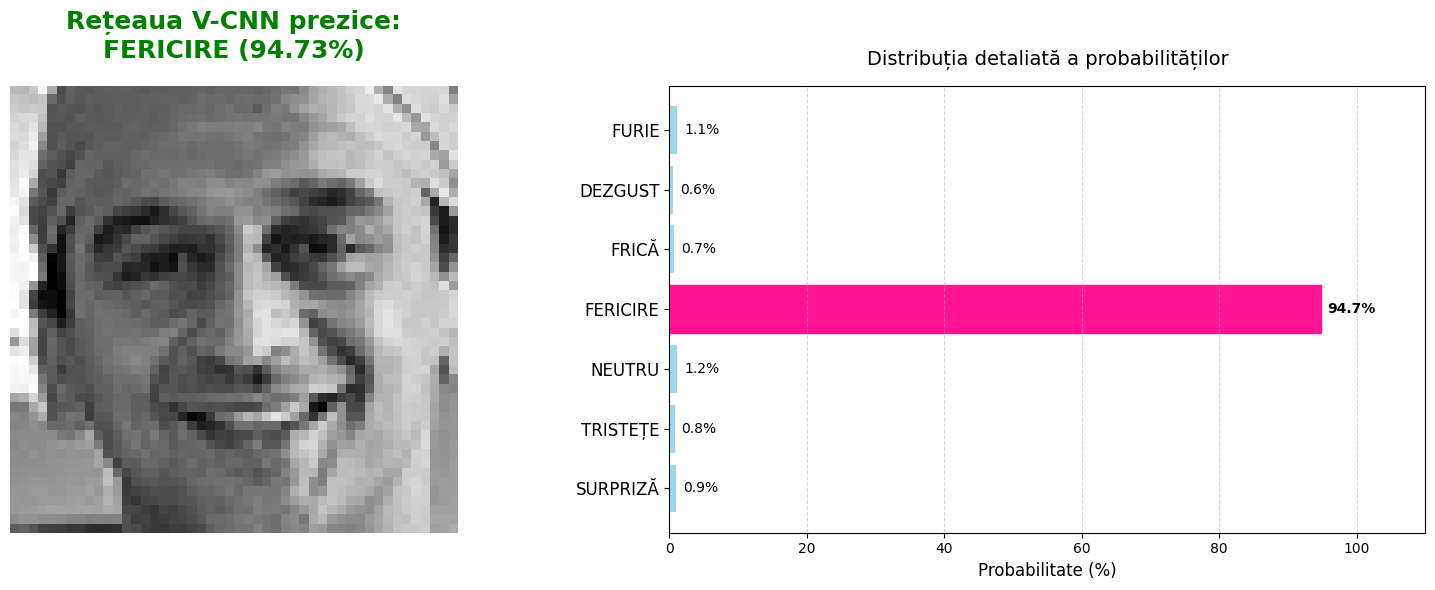

In [13]:
# === Testare Vizuală pe Imagini Individuale ===
# Funcția testeaza_cu_legenda() primește o cale de imagine și modelul antrenat,
# preprocesează imaginea identic cu pipeline-ul de antrenare (48×48, grayscale, [0,1]),
# rulează predicția și afișează un grafic cu 2 panouri:
#   - Stânga: imaginea originală + emoția prezisă (cu procent de încredere)
#   - Dreapta: distribuția probabilităților softmax pentru toate 7 clase (în română)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def testeaza_cu_legenda(cale_imagine, model):
    etichete_en = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    
    clase_ro = {
        'angry': 'FURIE',
        'disgust': 'DEZGUST',
        'fear': 'FRICĂ',
        'happy': 'FERICIRE',
        'neutral': 'NEUTRU',
        'sad': 'TRISTEȚE',
        'surprise': 'SURPRIZĂ'
    }
    
    nume_ro_scurt = [clase_ro[e] for e in etichete_en]

    try:
        img_pt_model = image.load_img(cale_imagine, target_size=(48, 48), color_mode="grayscale")
    except Exception as e:
        print(f"Eroare la încărcarea imaginii: {e}")
        return

    img_array = image.img_to_array(img_pt_model)
    img_array = np.expand_dims(img_array, axis=0) 
    
    img_array = img_array / 255.0

    predictii_brute = model.predict(img_array, verbose=0)[0] 
    index_maxim = np.argmax(predictii_brute)
    
    emotie_w_en = etichete_en[index_maxim]
    emotie_w_ro = clase_ro[emotie_w_en]
    procent_w = predictii_brute[index_maxim] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    img_orig = cv2.imread(cale_imagine)
    if img_orig is None:
        print("Eroare: Nu am putut citi imaginea originală pentru afișare!")
        return
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    ax1.imshow(img_orig)
    ax1.axis('off') 
    
    culoare_titlu = 'green' if emotie_w_en == 'happy' else 'red' if emotie_w_en in ['angry', 'fear'] else 'darkblue'
    
    ax1.set_title(f"Rețeaua V-CNN prezice:\n{emotie_w_ro} ({procent_w:.2f}%)", 
                  fontsize=18, color=culoare_titlu, fontweight='bold', pad=20)

    y_pos = np.arange(len(nume_ro_scurt))
    procente_afisare = predictii_brute * 100
    
    bare = ax2.barh(y_pos, procente_afisare, align='center', color='skyblue', alpha=0.8)
    
    bare[index_maxim].set_color('deeppink')
    bare[index_maxim].set_alpha(1.0)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nume_ro_scurt, fontsize=12)
    ax2.invert_yaxis() 
    ax2.set_xlabel('Probabilitate (%)', fontsize=12)
    ax2.set_title('Distribuția detaliată a probabilităților', fontsize=14, pad=15)
    
    for i, bar in enumerate(bare):
        latime = bar.get_width()
        ax2.text(latime + 1, bar.get_y() + bar.get_height()/2, 
                 f'{procente_afisare[i]:.1f}%', 
                 va='center', fontsize=10, fontweight='bold' if i == index_maxim else 'normal')

    ax2.set_xlim(0, 110) 
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

testeaza_cu_legenda('/kaggle/input/datasets/msambare/fer2013/test/happy/PrivateTest_14053744.jpg', model)

In [ ]:
model.save('v_cnn_best_model_tpu.keras')

In [6]:
#am creeat un dataset in care am salvat toate modelele antrenate
#aici aplicam modelul nostru schimband calea acestuia la nevoie
from tensorflow.keras.models import load_model

cale_model = '/kaggle/input/datasets/mindrocrobert/modelulmeu/vrescnn_model_31martie.keras'
model = load_model(cale_model)

print("Modelul este acum încărcat în memorie")

Modelul este acum încărcat în memorie
